# Exercise 01 — Hidden Markov Model (HMM)

Consider the following HMM:

*Hidden Markov Model for inferring weather (hot = H, cold = C) from number of ice creams eaten.*

## Part (a)

What is the probability of traversing the path

$$
\text{start} \rightarrow C \rightarrow C \rightarrow \text{end}
$$

according to this HMM?

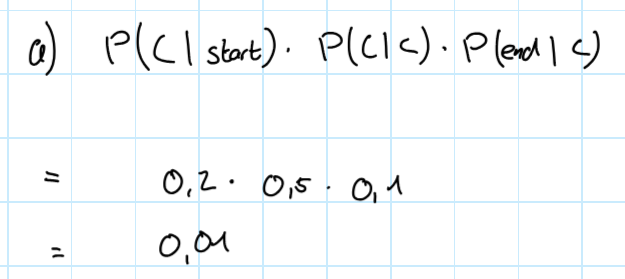

## Part (b)

What is the probability that, when observing the weather on three subsequent days, we encounter at least two consecutive cold days, i.e., the event

$$
C \rightarrow C
$$

occurs at least once?

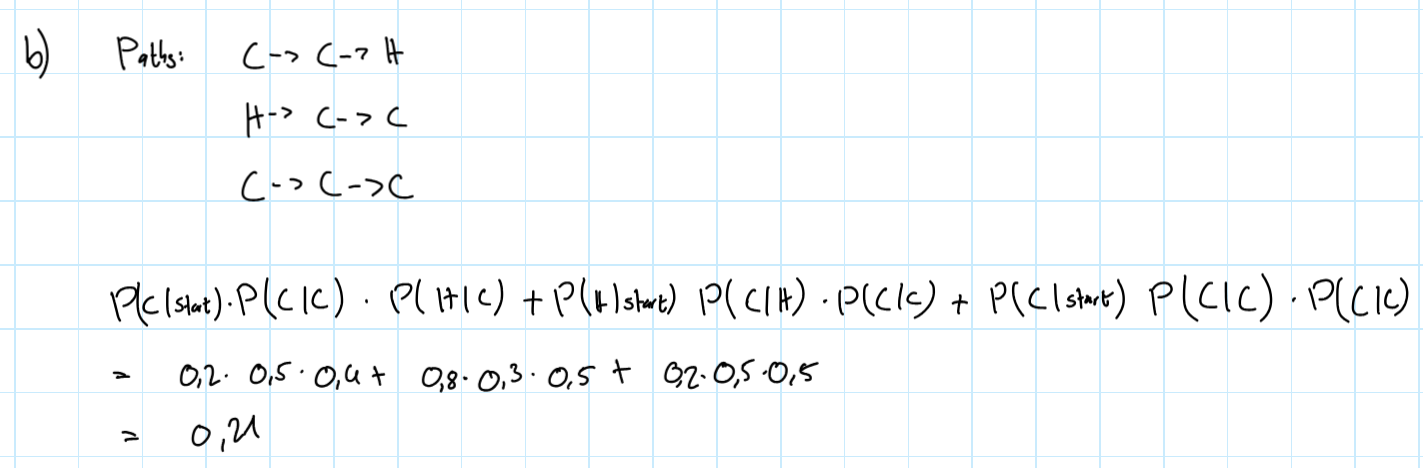

## Part (c)

What is the probability of the output sequence

$$
1\;\;3
$$

given this model?

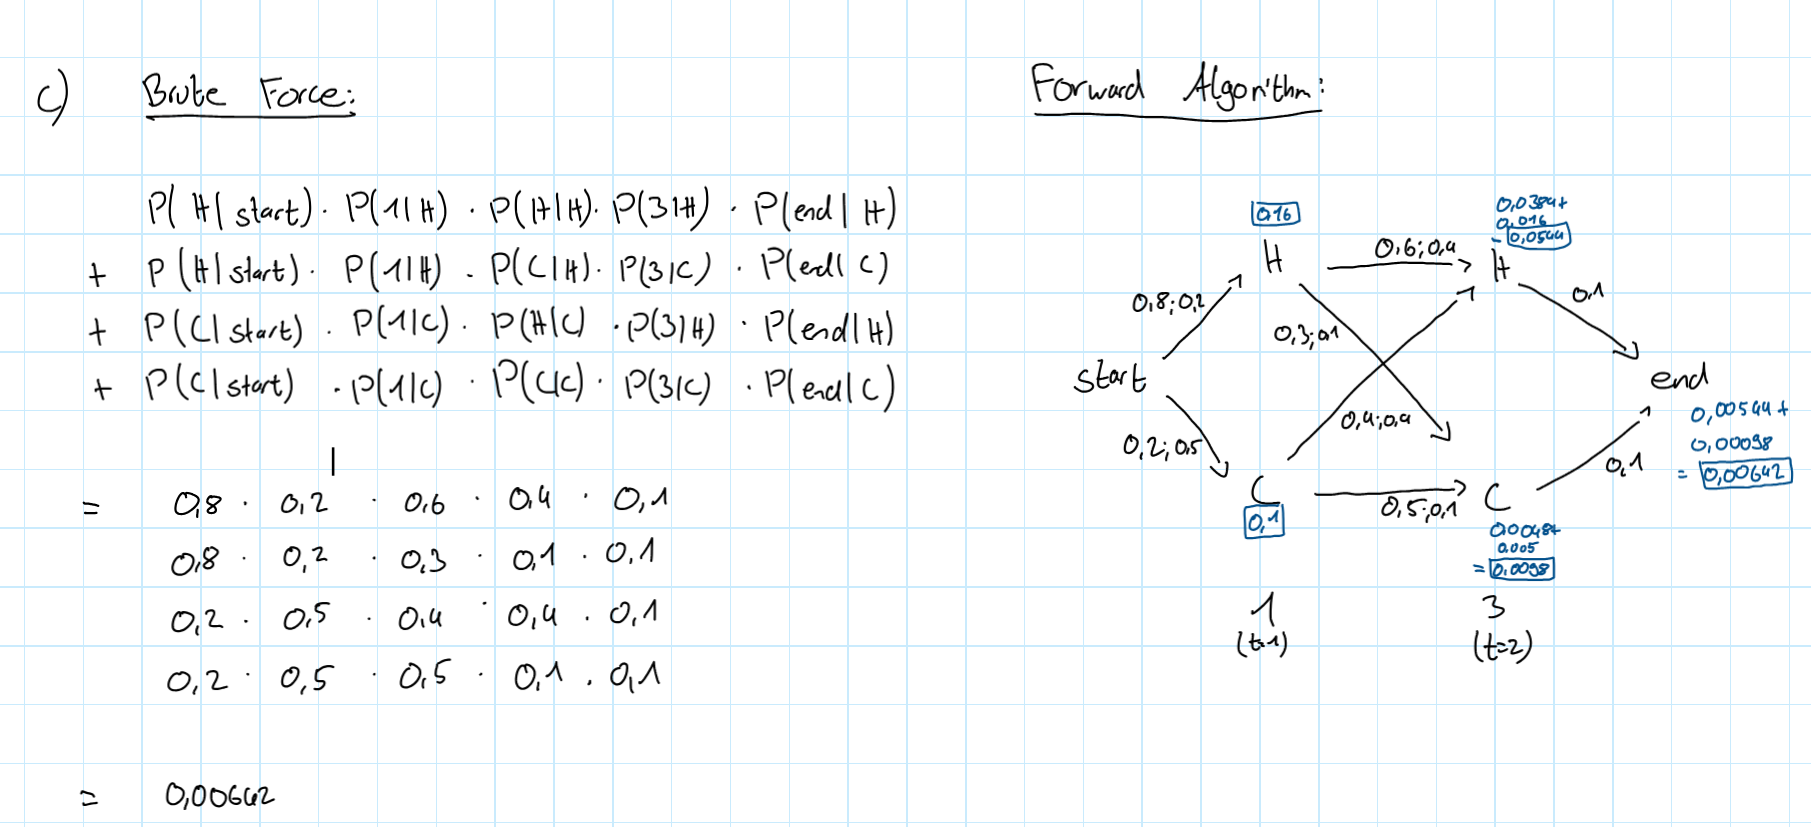

---

# Exercise 02

Suppose you have the following tagged corpus:

Each word is followed by its POS tag in brackets.

sent 1: (it PRO) (was AUX) (the OP) (telescreen N) (. .)  
sent 2: (the OP) (Thought N) (Police N) (used V) (the OP) (telescreen N) (. .)  
sent 3: (the OP) (Thought N) (Police N) (mattered V) (for P) (them PRO) (. .)  
sent 4: (Winston N) (kept V) (his OP) (back N) (turned V) (to P) (the OP) (telescreen N) (. .)  
sent 5: (Winston N) (wanted V) (to CLM) (turn V) (. .)  

The symbol `(. .)` denotes the end of a sentence.

## Part (a)

State the transition probabilities of the HMM that results from this corpus using Maximum Likelihood Estimation (MLE), i.e., by counting occurrences.

It is sufficient to draw the corresponding graph.

In [2]:
import pandas as pd

# The corpus from Exercise 2
corpus = [
    [("it", "PRO"), ("was", "AUX"), ("the", "OP"), ("telescreen", "N"), (".", ".")],
    [("the", "OP"), ("Thought", "N"), ("Police", "N"), ("used", "V"), ("the", "OP"), ("telescreen", "N"), (".", ".")],
    [("the", "OP"), ("Thought", "N"), ("Police", "N"), ("mattered", "V"), ("for", "P"), ("them", "PRO"), (".", ".")],
    [("Winston", "N"), ("kept", "V"), ("his", "OP"), ("back", "N"), ("turned", "V"), ("to", "P"), ("the", "OP"), ("telescreen", "N"), (".", ".")],
    [("Winston", "N"), ("wanted", "V"), ("to", "CLM"), ("turn", "V"), (".", ".")]
]

# Order of tags to match your table layout
tags = ["PRO", "AUX", "OP", "N", ".", "V", "P", "CLM"]
states_from = ["start"] + tags

# 1. Compute Raw Transition Counts
raw_counts = pd.DataFrame(0, index=states_from, columns=tags)

for sentence in corpus:
    # Transition from start to first tag
    start_tag = sentence[0][1]
    raw_counts.loc["start", start_tag] += 1
    
    # Internal transitionsk
    for i in range(len(sentence) - 1):
        tag_from = sentence[i][1]
        tag_to = sentence[i+1][1]
        raw_counts.loc[tag_from, tag_to] += 1

# 2. Standard HMM MLE Transition Probabilities (Row-normalized)
# Row sums represent total times transitions initiated from that state
row_sums = raw_counts.sum(axis=1)
mle_probs = raw_counts.div(row_sums, axis=0).fillna(0.0)

print("--- 1. RAW TRANSITION COUNTS ---")
print(raw_counts)
print("\n--- 2. ROW-NORMALIZED MLE PROBABILITIES ---")
print(mle_probs.round(4))

--- 1. RAW TRANSITION COUNTS ---
       PRO  AUX  OP  N  .  V  P  CLM
start    1    0   2  2  0  0  0    0
PRO      0    1   0  0  1  0  0    0
AUX      0    0   1  0  0  0  0    0
OP       0    0   0  6  0  0  0    0
N        0    0   0  2  3  5  0    0
.        0    0   0  0  0  0  0    0
V        0    0   2  0  1  0  2    1
P        1    0   1  0  0  0  0    0
CLM      0    0   0  0  0  1  0    0

--- 2. ROW-NORMALIZED MLE PROBABILITIES ---
       PRO  AUX      OP    N       .    V       P     CLM
start  0.2  0.0  0.4000  0.4  0.0000  0.0  0.0000  0.0000
PRO    0.0  0.5  0.0000  0.0  0.5000  0.0  0.0000  0.0000
AUX    0.0  0.0  1.0000  0.0  0.0000  0.0  0.0000  0.0000
OP     0.0  0.0  0.0000  1.0  0.0000  0.0  0.0000  0.0000
N      0.0  0.0  0.0000  0.2  0.3000  0.5  0.0000  0.0000
.      0.0  0.0  0.0000  0.0  0.0000  0.0  0.0000  0.0000
V      0.0  0.0  0.3333  0.0  0.1667  0.0  0.3333  0.1667
P      0.5  0.0  0.5000  0.0  0.0000  0.0  0.0000  0.0000
CLM    0.0  0.0  0.0000  0.0  

## Part (b)

Give all emission probabilities that:

- contain the words  
  $$
  \text{"Winston"},\ \text{"mattered"},\ \text{"to"},\ \text{"them"},\ \text{"."}
  $$
- and are not equal to 0.

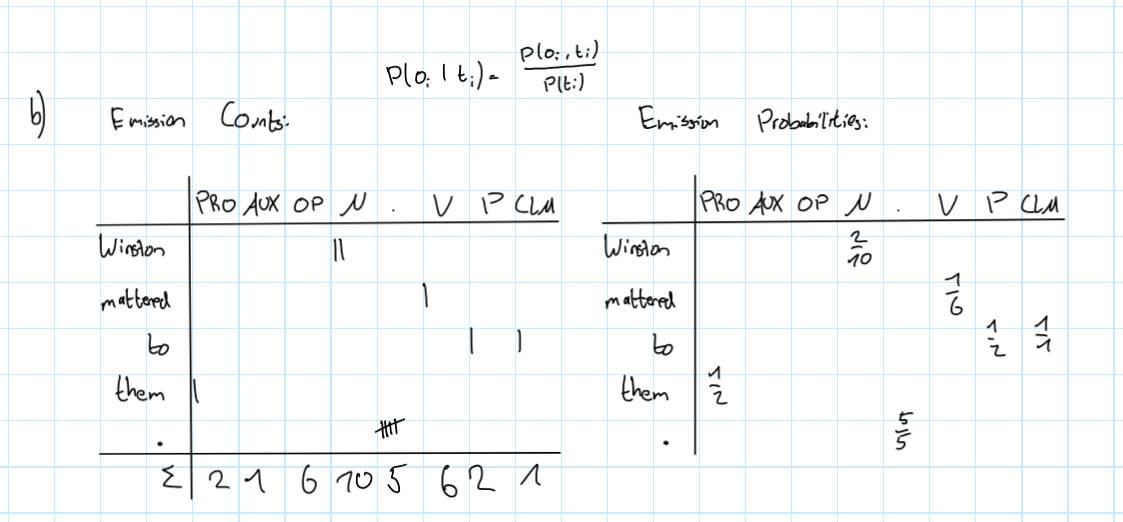

## Part (c)

Using this model, determine the best tag sequence for the sentence:

$$
\text{"Winston mattered to them ."}
$$

To answer this, compute the **Viterbi matrix** for this input.

It suffices to specify only the matrix entries that are not equal to 0.

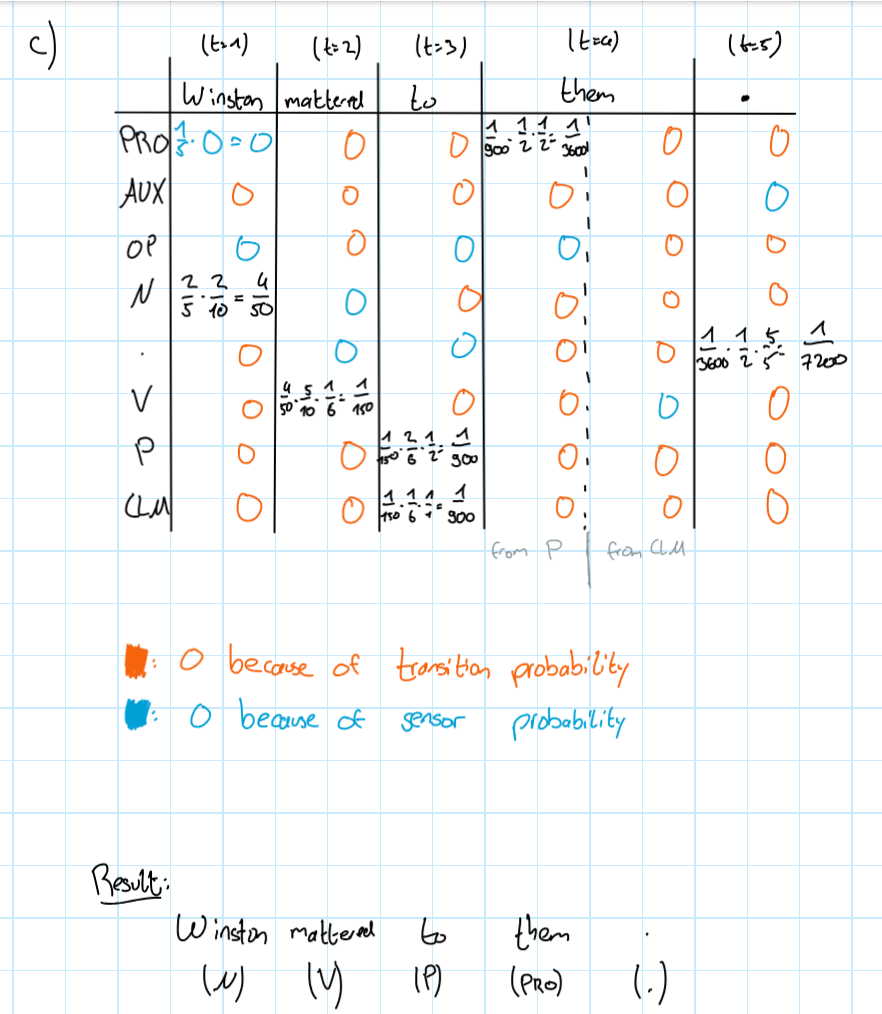